<video width="640" height="480" controls controlsList="nodownload" style="max-width: 100%;">
  <source src="https://github.com/gioferola/AN2DL_challenges/raw/main/video/Balene_Cartoon_per_Challenge_AI.mp4" type="video/mp4">
</video>

# Pirate Pain Classification - Bagging Ensemble Model

This notebook implements a **Bagging (Bootstrap Aggregating) Ensemble** approach using three different Recurrent Neural Networks (RNN, LSTM, GRU) to classify pirate pain levels from temporal sensor data.

## 🎯 Objective
Build a robust ensemble classifier that predicts pain levels (`no_pain`, `low_pain`, `high_pain`) by combining predictions from multiple diverse models trained on bootstrap samples.

## 📋 Table of Contents
1. [Setup & Imports](#setup)
2. [Hyperparameters](#hyperparameters)
3. [Data Loading & Preprocessing](#data)
4. [Model Architecture](#model)
5. [Training Process](#training)
6. [Ensemble Predictions](#ensemble)
7. [Submission Generation](#submission)

---

<a id="setup"></a>
## Setup & Imports

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.6.0+cu124
Device: cuda


---

<a id="hyperparameters"></a>
## Hyperparameters Configuration

Define hyperparameters for three different models in our bagging ensemble:
- **Model 1**: Bidirectional LSTM
- **Model 2**: Bidirectional RNN  
- **Model 3**: Bidirectional GRU

Each model uses different architectures and hyperparameters to ensure diversity in the ensemble.

### Global Configuration
Set experiment name and window parameters for sequence generation.

In [2]:
EXPERIMENT_NAME = 'RNN_LSTM_GRU'

# Define the window size
WINDOW_SIZE = 35

# Define the stride for overlapping windows
STRIDE = 5

writer = None

EXPERIMENT_NAME

'RNN_LSTM_GRU'

### Model 1 Hyperparameters: Bidirectional LSTM
- **Architecture**: 2-layer Bidirectional LSTM with 128 hidden units
- **Learning Rate**: 2e-3
- **Batch Size**: 128
- **No Dropout** (relying on ensemble diversity for regularization)

In [ ]:
# Training configuration
LEARNING_RATE = 2e-3
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2
HIDDEN_SIZE = 128 

# Regularization
DROPOUT_RATE = 0 
L1_LAMBDA = 0
L2_LAMBDA = 0

BIDIRECTIONAL = True
RNN_TYPE = "LSTM"

BATCH_SIZE = 128


### Model 2 Hyperparameters: Bidirectional RNN
- **Architecture**: 1-layer Bidirectional RNN with 256 hidden units
- **Learning Rate**: 4e-4
- **Batch Size**: 128
- Simpler architecture but larger hidden size

In [ ]:
# Training configuration
LEARNING_RATE_2 = 4e-4

# Architecture
HIDDEN_LAYERS_2 = 1
HIDDEN_SIZE_2 = 256

# Regularization
DROPOUT_RATE_2 = 0
L1_LAMBDA_2 = 0
L2_LAMBDA_2 = 0

BIDIRECTIONAL_2 = True
RNN_TYPE_2 = "RNN"

BATCH_SIZE_2 = 128

### Model 3 Hyperparameters: Bidirectional GRU
- **Architecture**: 2-layer Bidirectional GRU with 128 hidden units
- **Learning Rate**: 2e-3
- **Batch Size**: 256
- GRU offers a balance between LSTM complexity and RNN simplicity

In [ ]:
# Training configuration
LEARNING_RATE_3 = 2e-3

# Architecture
HIDDEN_LAYERS_3 = 2
HIDDEN_SIZE_3 = 128

# Regularization
DROPOUT_RATE_3 = 0
L1_LAMBDA_3 = 0
L2_LAMBDA_3 = 0 

BIDIRECTIONAL_3 = True
RNN_TYPE_3 = "GRU"

BATCH_SIZE_3 = 256

---

<a id="data"></a>
## Data Loading & Preprocessing

Load the pirate pain dataset and prepare it for model training. The dataset contains:
- **Training data**: Temporal sensor readings from pirates
- **Labels**: Pain levels (no_pain, low_pain, high_pain)
- **Test data**: Unlabeled sequences for final predictions

In [7]:

df = pd.read_csv('/kaggle/input/pirati/pirate_pain_train.csv')
y_train = pd.read_csv('/kaggle/input/pirati/pirate_pain_train_labels.csv')

X_test = pd.read_csv('/kaggle/input/pirati/pirate_pain_test.csv')

### Merge Features with Labels
Combine the training data with their corresponding labels for easier processing.

In [8]:
df = pd.merge(df, y_train, on='sample_index', how='inner')
print("Merged DataFrame created.")
df.head()

Merged DataFrame created.


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain


### Configure Loss Function with Class Weights
Handle class imbalance by computing balanced class weights. This ensures the model doesn't bias towards the majority class.

**Mathematical Formula:**

For each class $c$, the balanced weight is computed as:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples in class } c}}$$

Where:
- $w_c$ is the weight for class $c$
- $n_{\text{samples}}$ is the total number of samples
- $n_{\text{classes}}$ is the number of classes (3 in our case: no_pain, low_pain, high_pain)
- $n_{\text{samples in class } c}$ is the number of samples in class $c$

The weighted cross-entropy loss becomes:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} w_{y_i} \log(\hat{y}_i)$$

Where $w_{y_i}$ is the weight of the true class for sample $i$.

In [9]:
# Set up loss function and optimizer
if df['label'].dtype == object:
  mapping = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
  y_all = df['label'].map(mapping).values
else:
  y_all = df['label'].values

class_weights = compute_class_weight('balanced', classes=np.unique(y_all), y=y_all)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

### Data Exploration
Examine the dataset structure, types, and basic statistics.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

### Type Conversion
Convert joint features to float32 for efficient computation and memory usage.

In [11]:
for i in range(31):
    df[f'joint_{i:02d}'] = df[f'joint_{i:02d}'].astype(np.float32)
for i in range(31):
    X_test[f'joint_{i:02d}'] = X_test[f'joint_{i:02d}'].astype(np.float32)

In [12]:
df.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202049,0.197606,0.295603,0.300786,...,4.974359e-03,5.472111e-03,1.235068e-03,4.063172e-04,3.205551e-03,0.060292,0.079820,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746148e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800090e-06,3.079464e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


### Visualize Class Distribution
Check for class imbalance in the pain labels.

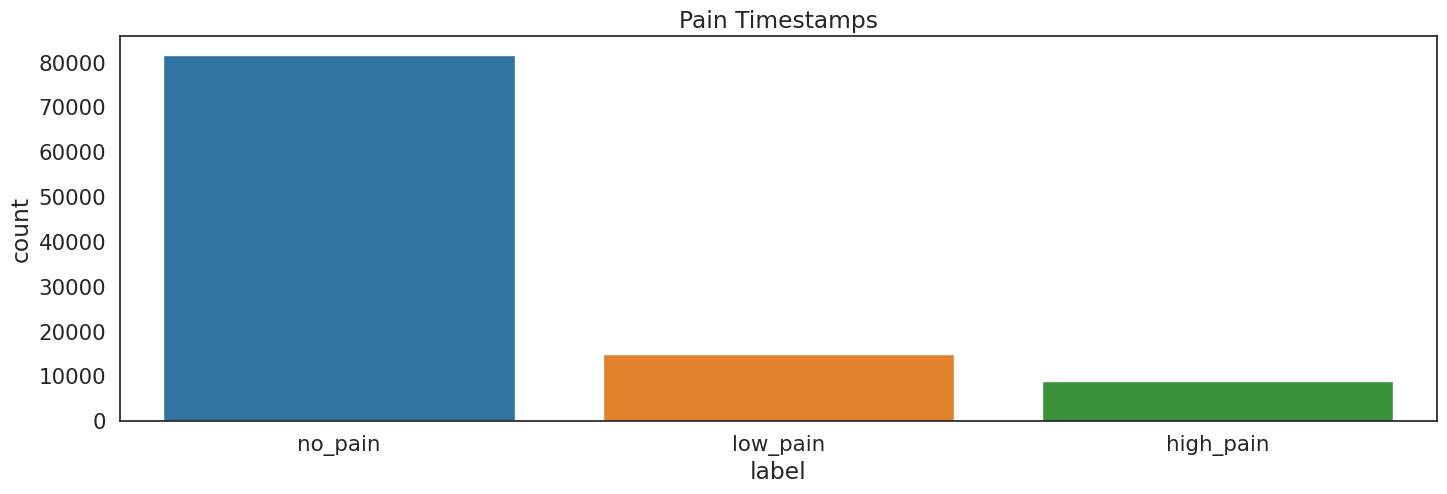

In [ ]:
# Visualise the count of timestamps for each type of pain
plt.figure(figsize=(17, 5))
sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index,
    palette='tab10'
)

plt.title('Pain Timestamps')

plt.show()

---

## Data Preprocessing

Prepare the data for model training through:
1. Creating unique identifiers for each sample-label combination
2. Splitting data into train/validation sets
3. Normalizing features
4. Encoding categorical variables

### Create Unique IDs
Generate composite IDs to uniquely identify each sample-label combination for tracking purposes.

In [ ]:
# Identify unique pain executions per pirate by creating a composite ID
df['id'] = df['sample_index'].astype('str') + '_' + df['label'].astype('str')

### Train/Validation Split
Split data by sample_index to ensure proper time-series validation (120 samples for validation).

In [ ]:
# Get unique pirate IDs and shuffle them
unique_users = df['sample_index'].unique()
random.seed(SEED) # Ensure reproducibility of shuffling
random.shuffle(unique_users)

# Define the number of pirates for validation set
N_VAL_USERS = 120

# Calculate the number of pirates for the training set
n_train_users = len(unique_users) - N_VAL_USERS

# Split the shuffled user IDs into training and validation
train_users = unique_users[:n_train_users]
val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]

# Split the dataset into training, validation
df_train = df[df['sample_index'].isin(train_users)]
df_val = df[df['sample_index'].isin(val_users)]

print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')

Training set shape: (86560, 42)
Validation set shape: (19200, 42)


### Verify Label Distribution
Check the class balance in training and validation sets.

In [ ]:
# Initialise a dictionary to count occurrences of each pain in the training set
training_labels = {
    'no_pain': 0,
    'high_pain': 0,
    'low_pain': 0
}

# Count occurrences of each pain for unique IDs in the training set
for id in df_train['id'].unique():
    label = df_train[df_train['id'] == id]['label'].values[0]
    training_labels[label] += 1

print('Training labels:', training_labels)

Training labels: {'no_pain': 419, 'high_pain': 46, 'low_pain': 76}


In [ ]:
# Initialise a dictionary to count occurrences of each pain in the validatoin set
validation_labels = {
    'no_pain': 0,
    'high_pain': 0,
    'low_pain': 0
}

# Count occurrences of each pain for unique IDs in the validation set
for id in df_val['id'].unique():
    label = df_val[df_val['id'] == id]['label'].values[0]
    validation_labels[label] += 1

print('Validation labels:', validation_labels)

Validation labels: {'no_pain': 92, 'high_pain': 10, 'low_pain': 18}


### Feature Normalization
Apply Min-Max normalization to joint and pain features using training set statistics.

**Important**: We exclude `joint_30` as it appears to be a constant feature.

In [18]:
joint_columns = [col for col in df.columns if col.startswith('joint_')]
pains_columns = [col for col in df.columns if col.startswith('pain')]

# Define the columns to be normalised
scale_columns = joint_columns + pains_columns
scale_columns.remove('joint_30')

# Calculate the minimum and maximum values from the training data only
mins = df_train[scale_columns].min()
maxs = df_train[scale_columns].max()

# Apply normalisation to the specified columns in all datasets
for column in scale_columns:
    # Normalise the training set
    df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])

    # Normalise the validation set
    df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])

    # Normalise the test set
    X_test[column] = (X_test[column] - mins[column]) / (maxs[column] - mins[column])

In [19]:
print(df_train.shape)
df_train.head()

(86560, 42)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,id
0,0,0,1.0,0.0,1.0,0.5,two,two,two,0.777507,...,0.000015,3.162814e-04,0.000004,0.014211,0.011376,0.018978,0.020291,0.5,no_pain,0_no_pain
1,0,1,1.0,1.0,1.0,1.0,two,two,two,0.806256,...,0.000022,9.828599e-07,0.000000,0.010745,0.000000,0.009473,0.010006,0.5,no_pain,0_no_pain
2,0,2,1.0,0.0,1.0,1.0,two,two,two,0.767592,...,0.000005,6.626013e-05,0.000003,0.013093,0.006830,0.017065,0.016856,0.5,no_pain,0_no_pain
3,0,3,1.0,1.0,1.0,1.0,two,two,two,0.666220,...,0.000007,1.199337e-06,0.000000,0.009502,0.006274,0.020264,0.017981,0.5,no_pain,0_no_pain
4,0,4,1.0,1.0,1.0,1.0,two,two,two,0.774297,...,0.000006,1.307199e-06,0.000007,0.004212,0.002132,0.023389,0.018477,0.5,no_pain,0_no_pain


### Label Encoding
Convert string labels to integers for model training:
- `no_pain` → 0
- `low_pain` → 1  
- `high_pain` → 2

In [20]:
# Define a mapping of pain names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

# Map pain names to integers in the training set
df_train['label'] = df_train['label'].map(label_mapping)

# Map pain names to integers in the validation set
df_val['label'] = df_val['label'].map(label_mapping)

### Encode Categorical Features
Convert pirate physical attributes to numerical values:
- **Legs**: `two` → 2, `one+peg_leg` → 1
- **Hands**: `two` → 2, `one+hook_hand` → 1
- **Eyes**: `two` → 2, `one+eye_patch` → 1

In [21]:

# Define a mapping of leg names to integer labels
label_mapping = {
    'two': 2,
    'one+peg_leg': 1,
}

# Map leg names to integers in the training set
df_train['n_legs'] = df_train['n_legs'].map(label_mapping)

# Map leg names to integers in the validation set
df_val['n_legs'] = df_val['n_legs'].map(label_mapping)

X_test['n_legs'] = X_test['n_legs'].map(label_mapping)

# Define a mapping of hand names to integer labels
label_mapping = {
    'two': 2,
    'one+hook_hand': 1,
}

df_train['n_hands'] = df_train['n_hands'].map(label_mapping)

df_val['n_hands'] = df_val['n_hands'].map(label_mapping)

X_test['n_hands'] = X_test['n_hands'].map(label_mapping)


# Define a mapping of eyes names to integer labels
label_mapping = {
    'two': 2,
    'one+eye_patch': 1,
}

df_train['n_eyes'] = df_train['n_eyes'].map(label_mapping)

df_val['n_eyes'] = df_val['n_eyes'].map(label_mapping)

X_test['n_eyes'] = X_test['n_eyes'].map(label_mapping)

In [22]:
df_train.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
count,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,86560.000000,...,8.656000e+04,86560.000000,86560.000000,8.656000e+04,86560.000000,86560.000000,86560.000000,86560.000000,86560.0,86560.000000
mean,329.508318,79.500000,0.815631,0.826981,0.825913,0.831984,1.990758,1.990758,1.990758,0.669551,...,3.472707e-05,0.000118,0.000759,9.868020e-05,0.035346,0.051041,0.036105,0.046151,0.5,0.310536
std,189.164028,46.187386,0.341567,0.334991,0.333377,0.330392,0.095691,0.095691,0.095691,0.144511,...,4.633969e-03,0.004907,0.010531,3.689872e-03,0.051593,0.070112,0.043849,0.052777,0.0,0.619809
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.5,0.000000
25%,168.000000,39.750000,0.500000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.587777,...,1.387858e-07,0.000001,0.000008,7.559298e-07,0.007831,0.010686,0.011800,0.014888,0.5,0.000000
50%,333.000000,79.500000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.714176,...,7.068919e-07,0.000004,0.000023,3.262194e-06,0.018023,0.027470,0.023144,0.029533,0.5,0.000000
75%,493.000000,119.250000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.767633,...,2.184242e-06,0.000011,0.000067,1.027503e-05,0.040947,0.062845,0.042580,0.058937,0.5,0.000000
max,659.000000,159.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,...,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,0.5,2.000000


---

## Sequence Generation

Transform time-series data into fixed-length sequences using a sliding window approach.

**Parameters**:
- **Window Size**: 35 timesteps
- **Stride**: 5 timesteps (80% overlap for better temporal information capture)

### Define Sequence Builder Function

In [23]:
param = scale_columns + ['n_legs','n_hands','n_eyes']
def build_sequences(df, window=200, stride=200):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []


    for id in df['id'].unique():

        temp = df[df['id'] == id][param].values


        label = df[df['id'] == id]['label'].values[0]

        padding_len = window - len(temp) % window

        padding = np.zeros((padding_len, len(param)), dtype='float32')
        temp = np.concatenate((temp, padding))

        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            idx += stride

    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

### Generate Training & Validation Sequences
Create sequences for both training and validation sets.

In [25]:
# Generate sequences and labels for the training set
X_train, y_train = build_sequences(df_train, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the validation set
X_val, y_val = build_sequences(df_val, WINDOW_SIZE, STRIDE)

In [26]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((15689, 35, 37), (15689,), (3480, 35, 37), (3480,))

In [27]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

### Create PyTorch Datasets
Convert NumPy arrays to PyTorch TensorDatasets for efficient batching.

In [28]:
import torch.nn.functional as F

# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val))

### DataLoader Configuration
Configure DataLoaders with optimizations:
- Multi-worker data loading
- Pin memory for faster GPU transfer
- Prefetching for reduced training time

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

In [30]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break

Features batch shape: torch.Size([128, 35, 37])
Labels batch shape: torch.Size([128])


---

<a id="model"></a>
## Model Architecture

Define the Recurrent Neural Network architecture that will be used for all three models in the ensemble.

**Key Features**:
- Supports RNN, LSTM, and GRU architectures
- Bidirectional processing for better temporal understanding
- Flexible number of layers and hidden units
- Dropout regularization between layers

In [32]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits

---

<a id="training"></a>
## Training Process

Define training functions and implement early stopping with model checkpointing.

### Training Components:
1. **train_one_epoch**: Single epoch training with L1/L2 regularization
2. **validate_one_epoch**: Validation without gradient updates
3. **fit**: Complete training loop with early stopping

In [35]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [36]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [37]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

---

## Bootstrap Sampling (Bagging)

Create diverse training sets for each model using bootstrap sampling (sampling with replacement).

**Why Bagging?**
- Reduces overfitting by training on different data subsets
- Increases model diversity in the ensemble
- Each model sees slightly different patterns
- Improves generalization through variance reduction

In [38]:
def create_bootstrap_sample(X, y, seed=None):
    """
    Create a bootstrap sample (random sample with replacement) from the training data.
    
    Args:
        X (np.ndarray): Training features
        y (np.ndarray): Training labels
        seed (int, optional): Random seed for reproducibility
    
    Returns:
        tuple: (X_bootstrap, y_bootstrap) - Bootstrap sample of features and labels
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_samples = len(X)
    # Sample with replacement
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    X_bootstrap = X[bootstrap_indices]
    y_bootstrap = y[bootstrap_indices]
    
    return X_bootstrap, y_bootstrap

# Create 3 different bootstrap samples for the 3 models
print("Creating bootstrap samples for bagging...")

X_train_boot1, y_train_boot1 = create_bootstrap_sample(X_train, y_train, seed=SEED + 1)
X_train_boot2, y_train_boot2 = create_bootstrap_sample(X_train, y_train, seed=SEED + 2)
X_train_boot3, y_train_boot3 = create_bootstrap_sample(X_train, y_train, seed=SEED + 3)

print(f"Bootstrap sample 1: {X_train_boot1.shape}")
print(f"Bootstrap sample 2: {X_train_boot2.shape}")
print(f"Bootstrap sample 3: {X_train_boot3.shape}")

# Create DataLoaders for each bootstrap sample
train_ds_boot1 = TensorDataset(torch.from_numpy(X_train_boot1).float(), torch.from_numpy(y_train_boot1))
train_ds_boot2 = TensorDataset(torch.from_numpy(X_train_boot2).float(), torch.from_numpy(y_train_boot2))
train_ds_boot3 = TensorDataset(torch.from_numpy(X_train_boot3).float(), torch.from_numpy(y_train_boot3))

train_loader_boot1 = make_loader(train_ds_boot1, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
train_loader_boot2 = make_loader(train_ds_boot2, batch_size=BATCH_SIZE_2, shuffle=True, drop_last=False)
train_loader_boot3 = make_loader(train_ds_boot3, batch_size=BATCH_SIZE_3, shuffle=True, drop_last=False)

print("Bootstrap DataLoaders created successfully!")

Creating bootstrap samples for bagging...
Bootstrap sample 1: (15689, 35, 37)
Bootstrap sample 2: (15689, 35, 37)
Bootstrap sample 3: (15689, 35, 37)
Bootstrap DataLoaders created successfully!


---

### Training Model 1: Bidirectional LSTM

Train the first model using:
- Bootstrap sample 1
- 2-layer Bidirectional LSTM
- 128 hidden units
- AdamW optimizer with learning rate 2e-3

In [ ]:
first_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    rnn_type=RNN_TYPE
).to(device)

optimizer = torch.optim.AdamW(first_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

first_model, history_1 = fit(
    model=first_model,
    train_loader=train_loader_boot1,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA,
    l2_lambda=0,
    patience=PATIENCE,
    evaluation_metric="val_f1",
    mode='max',
    restore_best_weights=True,
    writer=writer,
    verbose=10,
    experiment_name=EXPERIMENT_NAME+"_1"
)

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.9936, F1 Score=0.6516 | Val: Loss=0.9410, F1 Score=0.7045
Epoch  10/500 | Train: Loss=0.3481, F1 Score=0.8793 | Val: Loss=0.5711, F1 Score=0.8942
Epoch  20/500 | Train: Loss=0.1485, F1 Score=0.9309 | Val: Loss=0.6680, F1 Score=0.8281
Epoch  30/500 | Train: Loss=0.0615, F1 Score=0.9684 | Val: Loss=0.8426, F1 Score=0.8628
Epoch  40/500 | Train: Loss=0.0934, F1 Score=0.9608 | Val: Loss=0.6865, F1 Score=0.8731
Epoch  50/500 | Train: Loss=0.0631, F1 Score=0.9700 | Val: Loss=1.0095, F1 Score=0.8888
Epoch  60/500 | Train: Loss=0.0347, F1 Score=0.9812 | Val: Loss=0.7982, F1 Score=0.8884
Epoch  70/500 | Train: Loss=0.0255, F1 Score=0.9843 | Val: Loss=1.1016, F1 Score=0.8959
Epoch  80/500 | Train: Loss=0.0358, F1 Score=0.9845 | Val: Loss=0.8618, F1 Score=0.9066
Epoch  90/500 | Train: Loss=0.0264, F1 Score=0.9874 | Val: Loss=1.0495, F1 Score=0.9114
Epoch 100/500 | Train: Loss=0.0125, F1 Score=0.9927 | Val: Loss=1.4405, F1 Score=0.9061
Epoch 110

---

### Training Model 2: Bidirectional RNN

Train the second model using:
- Bootstrap sample 2
- 1-layer Bidirectional RNN
- 256 hidden units
- AdamW optimizer with learning rate 4e-4

In [ ]:
second_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=HIDDEN_SIZE_2,
    num_layers=HIDDEN_LAYERS_2,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE_2,
    bidirectional=BIDIRECTIONAL_2,
    rnn_type=RNN_TYPE_2
).to(device)
optimizer = torch.optim.AdamW(second_model.parameters(),lr=LEARNING_RATE_2,weight_decay=L2_LAMBDA_2)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

second_model, history_2 = fit(
    model=second_model,
    train_loader=train_loader_boot2,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA_2,
    l2_lambda=0,
    patience=PATIENCE,
    evaluation_metric="val_f1",
    mode='max',
    restore_best_weights=True,
    writer=writer,
    verbose=10,
    experiment_name=EXPERIMENT_NAME+"_2"
)

Training 500 epochs...
Epoch   1/500 | Train: Loss=1.0553, F1 Score=0.5604 | Val: Loss=1.0376, F1 Score=0.6702
Epoch  10/500 | Train: Loss=0.7992, F1 Score=0.6873 | Val: Loss=0.9603, F1 Score=0.5218
Epoch  20/500 | Train: Loss=0.4745, F1 Score=0.8359 | Val: Loss=0.8469, F1 Score=0.7249
Epoch  30/500 | Train: Loss=0.3314, F1 Score=0.8737 | Val: Loss=0.6897, F1 Score=0.8489
Epoch  40/500 | Train: Loss=0.2568, F1 Score=0.9039 | Val: Loss=0.7276, F1 Score=0.8710
Epoch  50/500 | Train: Loss=0.2017, F1 Score=0.9209 | Val: Loss=0.8536, F1 Score=0.7751
Epoch  60/500 | Train: Loss=0.1864, F1 Score=0.9236 | Val: Loss=0.7940, F1 Score=0.8446
Epoch  70/500 | Train: Loss=0.1482, F1 Score=0.9368 | Val: Loss=0.6184, F1 Score=0.8768
Epoch  80/500 | Train: Loss=0.1223, F1 Score=0.9483 | Val: Loss=0.7253, F1 Score=0.8737
Epoch  90/500 | Train: Loss=0.1157, F1 Score=0.9537 | Val: Loss=0.6796, F1 Score=0.8800
Epoch 100/500 | Train: Loss=0.1244, F1 Score=0.9519 | Val: Loss=0.9078, F1 Score=0.8830
Epoch 110

---

### Training Model 3: Bidirectional GRU

Train the third model using:
- Bootstrap sample 3
- 2-layer Bidirectional GRU
- 128 hidden units
- RAdam optimizer (more robust variant of Adam)
- Batch size 256

In [ ]:
third_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=HIDDEN_SIZE_3,
    num_layers=HIDDEN_LAYERS_3,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE_3,
    bidirectional=BIDIRECTIONAL_3,
    rnn_type=RNN_TYPE_3
).to(device)

optimizer = torch.optim.RAdam(third_model.parameters(), lr=LEARNING_RATE_3,weight_decay=L2_LAMBDA_3)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

third_model, history_3 = fit(
    model=third_model,
    train_loader=train_loader_boot3,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA_3,
    l2_lambda=0,
    patience=PATIENCE,
    evaluation_metric="val_f1",
    mode='max',
    restore_best_weights=True,
    writer=writer,
    verbose=10,
    experiment_name=EXPERIMENT_NAME+"_3"
)

Training 500 epochs...
Epoch   1/500 | Train: Loss=1.0819, F1 Score=0.5385 | Val: Loss=1.0046, F1 Score=0.7292
Epoch  10/500 | Train: Loss=0.4200, F1 Score=0.8673 | Val: Loss=0.5520, F1 Score=0.8433
Epoch  20/500 | Train: Loss=0.1068, F1 Score=0.9493 | Val: Loss=0.6985, F1 Score=0.8892
Epoch  30/500 | Train: Loss=0.1994, F1 Score=0.9243 | Val: Loss=0.8332, F1 Score=0.8123
Epoch  40/500 | Train: Loss=0.0268, F1 Score=0.9854 | Val: Loss=0.9710, F1 Score=0.9128
Epoch  50/500 | Train: Loss=0.0841, F1 Score=0.9628 | Val: Loss=0.8696, F1 Score=0.9051
Epoch  60/500 | Train: Loss=0.0707, F1 Score=0.9711 | Val: Loss=0.8334, F1 Score=0.8976
Epoch  70/500 | Train: Loss=0.0540, F1 Score=0.9737 | Val: Loss=0.9967, F1 Score=0.9040
Epoch  80/500 | Train: Loss=0.0092, F1 Score=0.9953 | Val: Loss=1.0952, F1 Score=0.8630
Epoch  90/500 | Train: Loss=0.0108, F1 Score=0.9936 | Val: Loss=1.2407, F1 Score=0.9127
Epoch 100/500 | Train: Loss=0.0060, F1 Score=0.9965 | Val: Loss=1.2705, F1 Score=0.9105
Early sto

---
<a id="ensemble"></a>
## Ensemble Predictions

Combine predictions from all three models using **majority voting**.

**How it works**:
1. Each model makes independent predictions
2. For each sample, take the most frequent prediction across all models
3. This reduces individual model errors and improves robustness

In [42]:
from scipy import stats

def get_ensemble_predictions(models, data_loader, device):
    """
    Get ensemble predictions from multiple models using majority voting.
    
    Args:
        models (list): List of trained models
        data_loader (DataLoader): DataLoader for the data to predict
        device (torch.device): Device to run inference on
    
    Returns:
        np.ndarray: Ensemble predictions
    """
    all_model_predictions = []
    
    # Get predictions from each model
    for model in models:
        model.eval()
        model_preds = []
        
        with torch.no_grad():
            for batch in data_loader:
                if len(batch) == 2:  # Training/validation data (has labels)
                    inputs, _ = batch
                else:  # Test data (no labels)
                    inputs = batch[0]
                
                inputs = inputs.to(device)
                
                with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                    logits = model(inputs)
                
                preds = logits.argmax(dim=1).cpu().numpy()
                model_preds.append(preds)
        
        model_preds = np.concatenate(model_preds)
        all_model_predictions.append(model_preds)
    
    # Stack predictions: shape (n_models, n_samples)
    all_model_predictions = np.array(all_model_predictions)
    
    # Majority voting (mode along axis=0)
    ensemble_preds, _ = stats.mode(all_model_predictions, axis=0, keepdims=False)
    
    return ensemble_preds

print("Ensemble prediction function defined.")

Ensemble prediction function defined.


Getting ensemble predictions on validation set...

BAGGING ENSEMBLE RESULTS ON VALIDATION SET
Accuracy:  0.9385
Precision: 0.9370
Recall:    0.9385
F1 Score:  0.9375


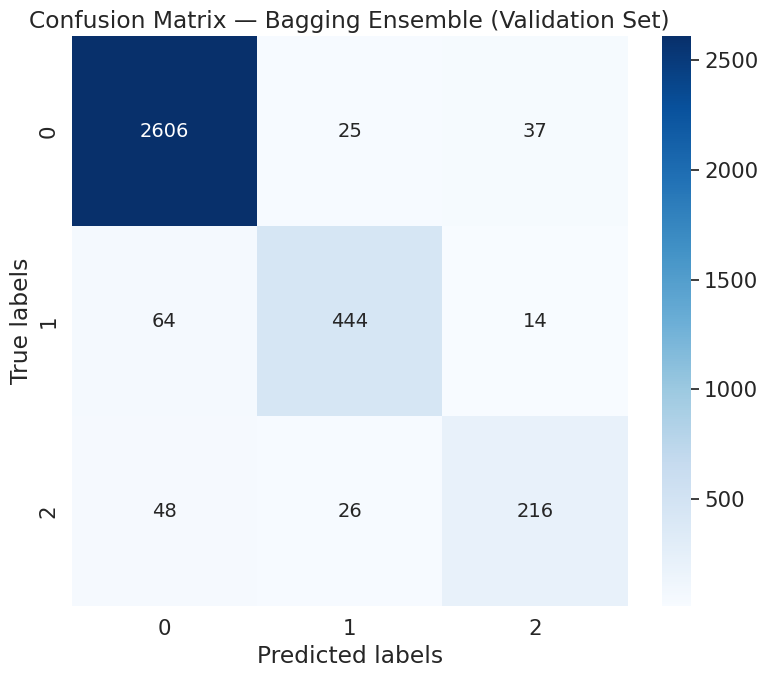

In [43]:
# Evaluate ensemble on validation set
models = [first_model, second_model, third_model]

print("Getting ensemble predictions on validation set...")
ensemble_val_preds = get_ensemble_predictions(models, val_loader, device)

# Calculate ensemble metrics
ensemble_acc = accuracy_score(y_val, ensemble_val_preds)
ensemble_prec = precision_score(y_val, ensemble_val_preds, average='weighted')
ensemble_rec = recall_score(y_val, ensemble_val_preds, average='weighted')
ensemble_f1 = f1_score(y_val, ensemble_val_preds, average='weighted')

print("\n" + "="*60)
print("BAGGING ENSEMBLE RESULTS ON VALIDATION SET")
print("="*60)
print(f"Accuracy:  {ensemble_acc:.4f}")
print(f"Precision: {ensemble_prec:.4f}")
print(f"Recall:    {ensemble_rec:.4f}")
print(f"F1 Score:  {ensemble_f1:.4f}")
print("="*60)

# Generate confusion matrix for the ensemble
cm_ensemble = confusion_matrix(y_val, ensemble_val_preds)
labels = np.array([f"{num}" for num in cm_ensemble.flatten()]).reshape(cm_ensemble.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_ensemble, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Bagging Ensemble (Validation Set)')
plt.tight_layout()
plt.show()

---

<a id="submission"></a>
## Test Set Preparation

Prepare the test data for generating final predictions.

In [44]:
X_test['id'] = X_test['sample_index'].astype('str')
print("Added 'id' column to X_test.")

Added 'id' column to X_test.


In [ ]:
def build_test_sequences(df, window=200, stride=200):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding sample indices
    dataset = []
    sample_indices = []

    for sample_idx in df['sample_index'].unique():
        # Create a temporary dataframe for the current sample_index
        temp_df = df[df['sample_index'] == sample_idx]

        # Extract features from the temporary dataframe
        temp_features = temp_df[param].values

        # Calculate padding length
        padding_len = window - len(temp_features) % window
        if padding_len == window:
            padding_len = 0

        # Apply padding if necessary
        if padding_len > 0:
            padding = np.zeros((padding_len, temp_features.shape[1]), dtype='float32')
            temp_features = np.concatenate((temp_features, padding))

        idx = 0
        while idx + window <= len(temp_features):
            dataset.append(temp_features[idx:idx + window])
            sample_indices.append(sample_idx)
            idx += stride

    dataset = np.array(dataset, dtype=np.float32)
    sample_indices = np.array(sample_indices)

    return dataset, sample_indices

print("build_test_sequences function defined.")

build_test_sequences function defined.


### Build Test Sequences
Create sequences from test data with proper handling of incomplete windows.

In [46]:
X_test_sequences, X_test_sample_indices = build_test_sequences(X_test, WINDOW_SIZE, STRIDE)
print(f"Generated {X_test_sequences.shape[0]} sequences for the test set.")

Generated 38396 sequences for the test set.


In [47]:
test_ds = TensorDataset(torch.from_numpy(X_test_sequences).float())
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print("Test DataLoader created.")

Test DataLoader created.


In [48]:
# Get ensemble predictions on test set
print("Getting ensemble predictions on test set...")
ensemble_test_preds = get_ensemble_predictions(models, test_loader, device)

print(f"Generated {len(ensemble_test_preds)} ensemble predictions for test set")
print(f"Sample predictions: {ensemble_test_preds[:10]}")

Getting ensemble predictions on test set...
Generated 38396 ensemble predictions for test set
Sample predictions: [0 0 0 0 0 0 0 0 0 0]


### Generate Ensemble Predictions on Test Set
Apply the trained ensemble to the test data.

In [49]:
# Create submission file with ensemble predictions
predictions_df = pd.DataFrame({
    'sample_index': X_test_sample_indices,
    'predicted_label': ensemble_test_preds
})

# Define reverse mapping for labels
reverse_label_mapping = {
    0: 'no_pain',
    1: 'low_pain',
    2: 'high_pain'
}

# Map integer predictions back to string labels
predictions_df['predicted_label_str'] = predictions_df['predicted_label'].map(reverse_label_mapping)

# Aggregate predictions by sample_index, taking the mode (most common prediction)
final_predictions = predictions_df.groupby('sample_index')['predicted_label_str'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
).reset_index()
final_predictions.rename(columns={'predicted_label_str': 'label'}, inplace=True)

# Convert sample_index to string and pad with leading zeros to at least 3 digits
final_predictions['sample_index'] = final_predictions['sample_index'].astype(str).str.zfill(3)

# Save the final ensemble predictions to a CSV file
ensemble_submission_file = 'submission_' + EXPERIMENT_NAME + '.csv'
final_predictions.to_csv(ensemble_submission_file, index=False, header=True)

print(f"\n✓ Bagging ensemble submission file '{ensemble_submission_file}' created successfully!")
print(f"  Total samples: {len(final_predictions)}")
print(f"\nLabel distribution in predictions:")
print(final_predictions['label'].value_counts().sort_index())


✓ Bagging ensemble submission file 'submission_RNN_LSTM_GRU.csv' created successfully!
  Total samples: 1324

Label distribution in predictions:
label
high_pain      96
low_pain      189
no_pain      1039
Name: count, dtype: int64


### Model Comparison Analysis
Compare the performance of individual models against the ensemble to understand:
- How much each model contributes to the final prediction
- Whether the ensemble provides meaningful improvement
- The diversity benefit of using different architectures and bootstrap samples

In [50]:
# Optional: Compare individual model predictions with ensemble on validation set
print("="*70)
print("COMPARISON: Individual Models vs Bagging Ensemble")
print("="*70)

# Get individual model predictions on validation set
val_preds_model1 = []
val_preds_model2 = []
val_preds_model3 = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        
        # Model 1
        logits1 = first_model(inputs)
        preds1 = logits1.argmax(dim=1).cpu().numpy()
        val_preds_model1.append(preds1)
        
        # Model 2
        logits2 = second_model(inputs)
        preds2 = logits2.argmax(dim=1).cpu().numpy()
        val_preds_model2.append(preds2)
        
        # Model 3
        logits3 = third_model(inputs)
        preds3 = logits3.argmax(dim=1).cpu().numpy()
        val_preds_model3.append(preds3)

val_preds_model1 = np.concatenate(val_preds_model1)
val_preds_model2 = np.concatenate(val_preds_model2)
val_preds_model3 = np.concatenate(val_preds_model3)

# Calculate F1 scores for each model
f1_model1 = f1_score(y_val, val_preds_model1, average='weighted')
f1_model2 = f1_score(y_val, val_preds_model2, average='weighted')
f1_model3 = f1_score(y_val, val_preds_model3, average='weighted')

print(f"\nModel 1 (Bootstrap Sample 1) - F1 Score: {f1_model1:.4f}")
print(f"Model 2 (Bootstrap Sample 2) - F1 Score: {f1_model2:.4f}")
print(f"Model 3 (Bootstrap Sample 3) - F1 Score: {f1_model3:.4f}")
print(f"\nBagging Ensemble (Majority Vote) - F1 Score: {ensemble_f1:.4f}")
print("\n" + "="*70)

# Show improvement
avg_individual = (f1_model1 + f1_model2 + f1_model3) / 3
improvement = ensemble_f1 - avg_individual
print(f"Average F1 of individual models: {avg_individual:.4f}")
print(f"Ensemble improvement: {improvement:+.4f} ({(improvement/avg_individual)*100:+.2f}%)")
print("="*70)

COMPARISON: Individual Models vs Bagging Ensemble

Model 1 (Bootstrap Sample 1) - F1 Score: 0.9385
Model 2 (Bootstrap Sample 2) - F1 Score: 0.9150
Model 3 (Bootstrap Sample 3) - F1 Score: 0.9358

Bagging Ensemble (Majority Vote) - F1 Score: 0.9375

Average F1 of individual models: 0.9298
Ensemble improvement: +0.0077 (+0.83%)
